In [36]:
%matplotlib inline

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import random

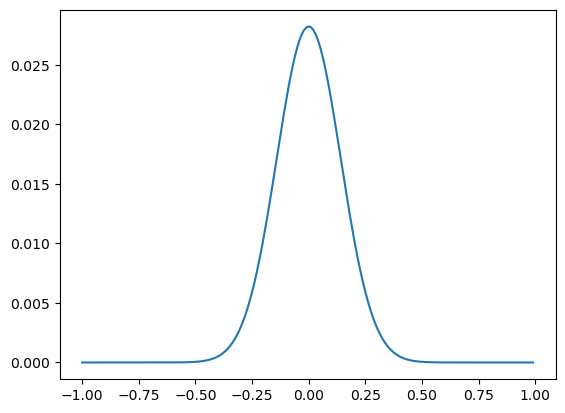

In [38]:
kernel_t = np.arange(-1., 1., 0.01)
kernel_tau = 0.2
#kernel = np.exp(-kernel_t / kernel_tau)
#kernel[:len(kernel_t)//2] = 0.
kernel = np.exp(-(kernel_t / kernel_tau)**2.)
kernel /= np.sum(kernel)
plt.plot(kernel_t, kernel)
plt.show()

In [4]:
def random_timeseries(initial_value: float, volatility: float, count: int) -> list:
    time_series = [initial_value, ]
    for _ in range(count):
        time_series.append(time_series[-1] + initial_value * random.gauss(0, 1) * volatility)
    return time_series

ts = random_timeseries(1.2, 0.15, 1000)

In [5]:
len(ts)

1001

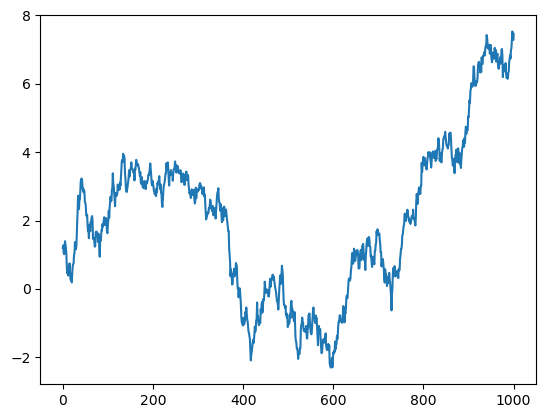

In [6]:
plt.plot(ts)

In [7]:
len(kernel_t)

200

In [8]:
len(ts)

1001

In [9]:
smoothed_ts = np.convolve(kernel, ts, mode='same')

In [10]:
len(smoothed_ts)

1001

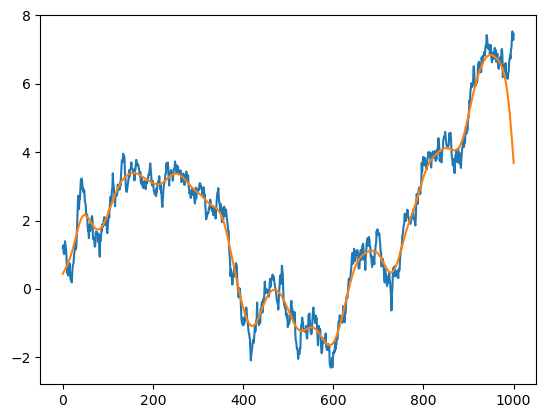

In [11]:
plt.plot(ts)
plt.plot(smoothed_ts)

Deconvolution doesn't work

In [12]:
q, r = scipy.signal.deconvolve(smoothed_ts, ts)

In [13]:
q

array([0.36696944])

In [14]:
len(q)

1

Frequency space division doesn't work

In [15]:
fft_ts = scipy.fft.fft(smoothed_ts)

In [16]:
fft_ts_freq = scipy.fft.fftfreq(len(smoothed_ts))

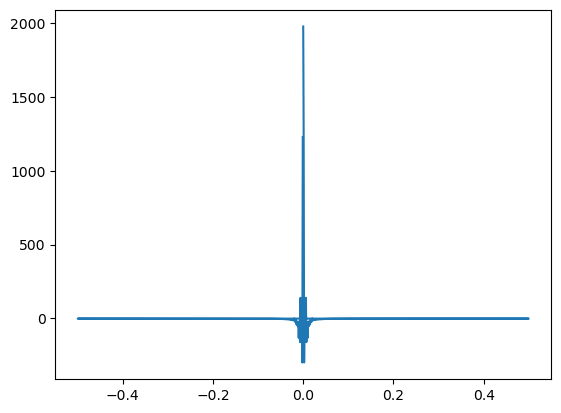

In [17]:
plt.plot(fft_ts_freq, fft_ts.real)

In [18]:
fft_kernel = scipy.fft.fft(kernel, n=len(smoothed_ts))
fft_kernel_freq = scipy.fft.fftfreq(len(smoothed_ts))

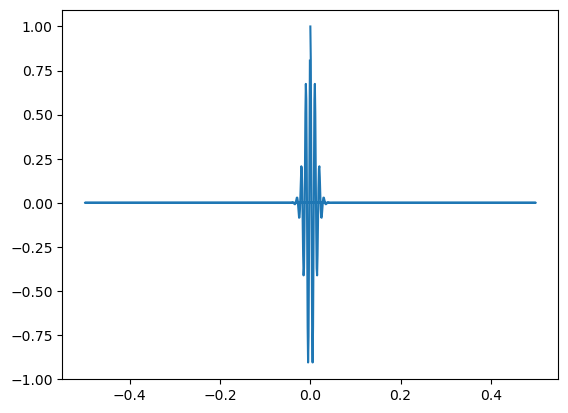

In [19]:
plt.plot(fft_kernel_freq, fft_kernel.real)

In [20]:
len(fft_kernel), len(fft_ts)

(1001, 1001)

In [21]:
fft_recovered = fft_ts / fft_kernel

In [22]:
recovered = scipy.fft.ifft(fft_recovered)

In [23]:
len(recovered)

1001

C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\cbook\__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


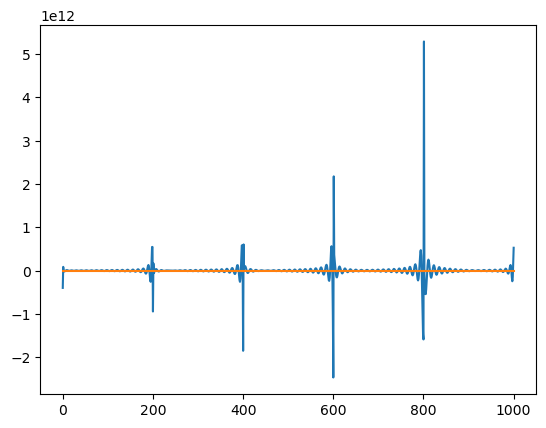

In [24]:
plt.plot(recovered)
plt.plot(ts)

In [25]:
fft_raw_ts = scipy.fft.fft(ts, n=len(ts))
fft_raw_ts_freq = scipy.fft.fftfreq(len(ts))

In [26]:
recovered_fft_kernel = fft_ts / fft_raw_ts

In [27]:
recovered_kernel = scipy.fft.ifft(recovered_fft_kernel)

In [28]:
len(recovered_kernel)

1001

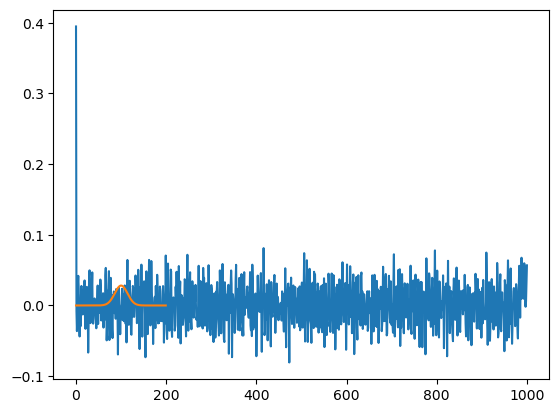

In [29]:
plt.plot(recovered_kernel)
plt.plot(kernel)

Parametric kernel optimization works

In [30]:
def blind_deconvolve_error(kernel, filtered_signal, orig_signal):    
    guess_filtered_signal = np.convolve(orig_signal, kernel, mode='same')[:len(orig_signal)]
    error = np.sum(np.square(filtered_signal - guess_filtered_signal))
    return error

In [31]:
from scipy.optimize import minimize

In [32]:
len(kernel)

200

In [33]:
init_guess_kernel = np.random.uniform(0, 1, len(kernel))
result = minimize(blind_deconvolve_error, x0=init_guess_kernel, args=(smoothed_ts, ts))

In [34]:
result

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 3.261499781191468e-11
        x: [-3.946e-08  1.821e-08 ...  6.068e-08 -2.943e-08]
      nit: 179
      jac: [-1.271e-06  9.762e-07 ...  8.834e-07  1.152e-06]
 hess_inv: [[ 3.332e-02 -5.461e-02 ...  4.960e-03 -5.024e-03]
            [-5.461e-02  1.104e-01 ... -1.183e-02  9.819e-03]
            ...
            [ 4.960e-03 -1.183e-02 ...  2.218e-01 -1.103e-01]
            [-5.024e-03  9.819e-03 ... -1.103e-01  9.306e-02]]
     nfev: 43416
     njev: 216

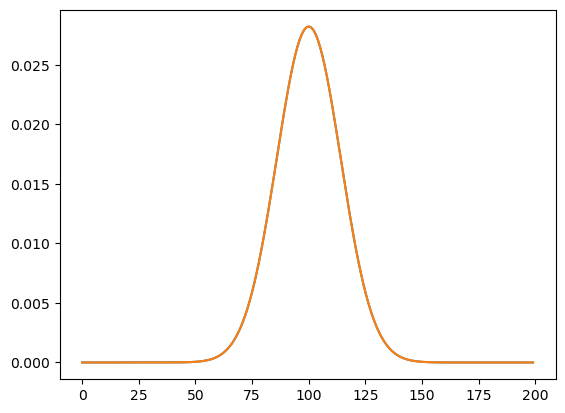

In [35]:
plt.plot(result.x)
plt.plot(kernel)

In [ ]:
#### make a causal and a acausal kernel 

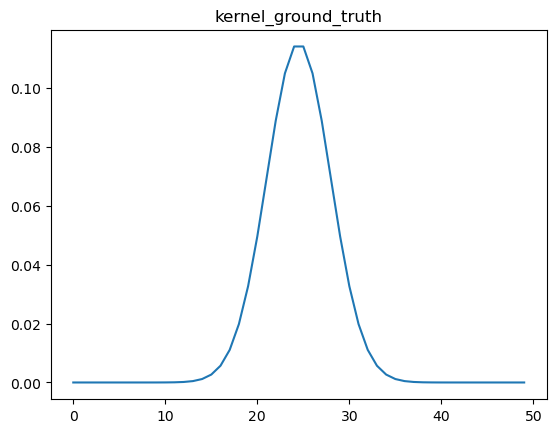

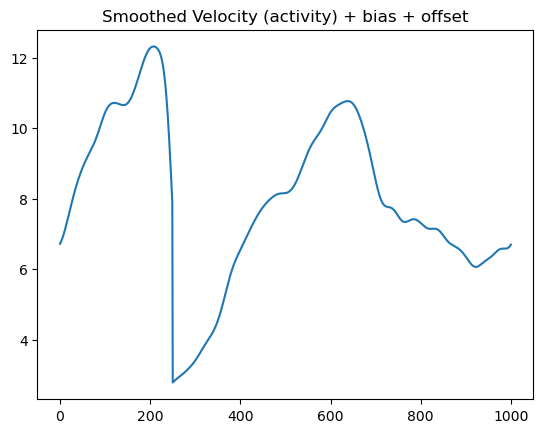

optimized_kernel 50


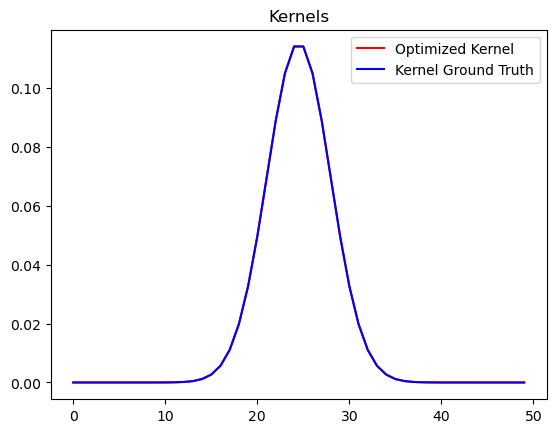

In [167]:
####### the original code 

def get_kernel(kernel_length=50, kernel_tau = 0.2, center=0.0):
    
    kernel_t = np.linspace(-1., 1., kernel_length)
    kernel = np.exp(-((kernel_t - center) / kernel_tau)**2.)
    kernel /= np.sum(kernel)
    return kernel 

kernel_ground_truth = get_kernel(kernel_length=50, kernel_tau = 0.2, center=0.0)

plt.figure()
plt.plot(kernel_ground_truth)
plt.title("kernel_ground_truth")
plt.show()

ts = random_timeseries(1.2, 0.15, 1000)

true_bias = 2.5

smoothed_ts_with_bias = np.convolve(kernel_ground_truth, ts, mode='same')
#smoothed_ts_with_bias = np.roll(smoothed_ts_with_bias.copy(), 250)
#smoothed_ts_with_bias = smoothed_ts_with_bias + true_bias 


plt.figure()
plt.plot(offset_smoothed_ts_with_bias)
plt.title("Smoothed Velocity (activity) + bias + offset")
plt.show()

def blind_deconvolve_error(kernel, filtered_signal, orig_signal):    
    guess_filtered_signal = np.convolve(orig_signal, kernel, mode='same')[:len(orig_signal)]
    error = np.sum(np.square(filtered_signal - guess_filtered_signal))
    return error

init_guess_kernel = np.random.uniform(0, 1, len(kernel_ground_truth))
result = minimize(blind_deconvolve_error, x0=init_guess_kernel, args=(smoothed_ts_with_bias, ts))

optimized_kernel = result.x
print(f"optimized_kernel {len(optimized_kernel)}")


plt.figure()
plt.plot(optimized_kernel, color='r', label="Optimized Kernel")
plt.plot(kernel_ground_truth, color='b', label="Kernel Ground Truth")
plt.title("Kernels")
plt.legend()
plt.show()


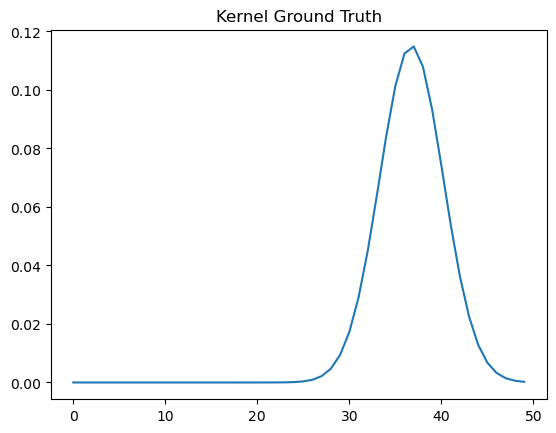

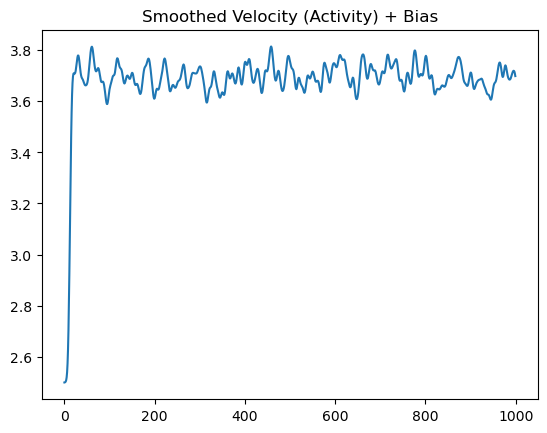

True Bias: 2.5
Optimized Bias: 2.4999998483914143


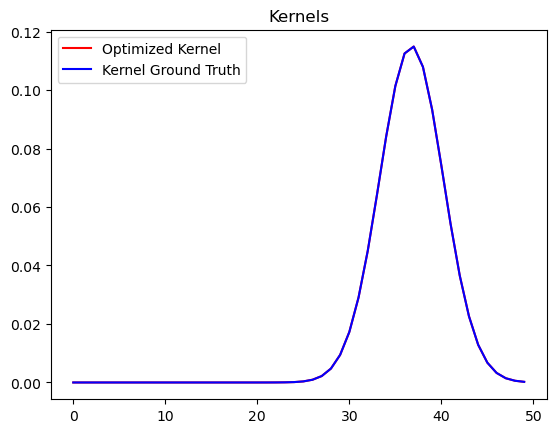

In [168]:
##### rolled the filtered signal and added findable bias term 
### winner 

import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def get_kernel(kernel_length=50, kernel_tau=0.2, center=0.0):
    kernel_t = np.linspace(-1., 1., kernel_length)
    kernel = np.exp(-((kernel_t - center) / kernel_tau)**2.)
    kernel /= np.sum(kernel)
    return kernel 


kernel_ground_truth = get_kernel(kernel_length=50, kernel_tau=0.2, center=0.5)

plt.figure()
plt.plot(kernel_ground_truth)
plt.title("Kernel Ground Truth")
plt.show()

def random_timeseries(mean, std, length):
    return np.random.normal(mean, std, length)

ts = random_timeseries(1.2, 0.15, 1000)

true_bias = 2.5  
true_offset = 200

smoothed_ts_with_bias = np.convolve(kernel_ground_truth, ts, mode='same')
#smoothed_ts_with_bias = np.roll(smoothed_ts_with_bias.copy(), true_offset)
smoothed_ts_with_bias = smoothed_ts_with_bias + true_bias

plt.figure()
plt.plot(smoothed_ts_with_bias)
plt.title("Smoothed Velocity (Activity) + Bias")
plt.show()

def blind_deconvolve_error(params, filtered_signal, orig_signal):    
    kernel = params[:-1] 
    bias = params[-1]  

    kernel /= np.sum(kernel)

    guess_filtered_signal = np.convolve(orig_signal, kernel, mode='same')[:len(orig_signal)] + bias

    error = np.sum(np.square(filtered_signal - guess_filtered_signal))
    return error

init_guess_kernel = np.random.uniform(0, 1, len(kernel_ground_truth))
init_guess_bias = [0.0] 
initial_guess = np.concatenate([init_guess_kernel, init_guess_bias])

bounds = [(0, 1)] * len(kernel_ground_truth) + [(-5, 5)]

result = minimize(blind_deconvolve_error, x0=initial_guess, args=(smoothed_ts_with_bias, ts), bounds=bounds)

optimized_kernel = result.x[:-1]
optimized_bias = result.x[-1]

optimized_kernel /= np.sum(optimized_kernel)

print(f"True Bias: {true_bias}")
print(f"Optimized Bias: {optimized_bias}")

plt.figure()
plt.plot(optimized_kernel, color='r', label="Optimized Kernel")
plt.plot(kernel_ground_truth, color='b', label="Kernel Ground Truth")
plt.title("Kernels")
plt.legend()
plt.show()


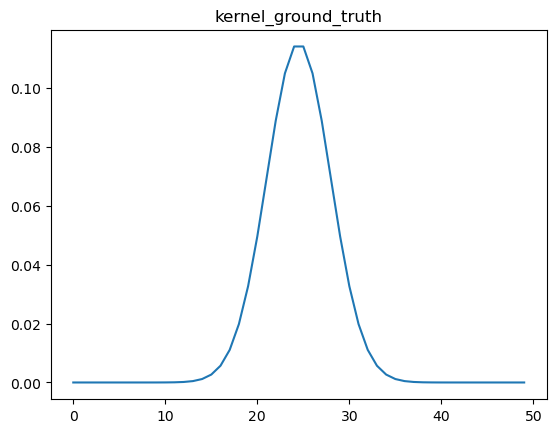

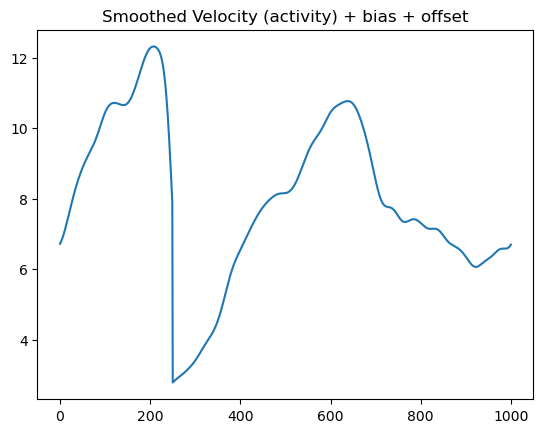

optimized_kernel 50


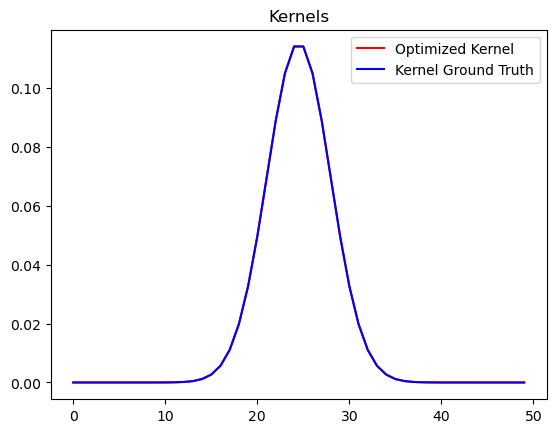

In [166]:
####### the original code 

def get_kernel(kernel_length=50, kernel_tau = 0.2, center=0.0):
    
    kernel_t = np.linspace(-1., 1., kernel_length)
    kernel = np.exp(-((kernel_t - center) / kernel_tau)**2.)
    kernel /= np.sum(kernel)
    return kernel 

kernel_ground_truth = get_kernel(kernel_length=50, kernel_tau = 0.2, center=0.0)

plt.figure()
plt.plot(kernel_ground_truth)
plt.title("kernel_ground_truth")
plt.show()

ts = random_timeseries(1.2, 0.15, 1000)

true_bias = 2.5

smoothed_ts_with_bias = np.convolve(kernel_ground_truth, ts, mode='same')
#smoothed_ts_with_bias = np.roll(smoothed_ts_with_bias.copy(), 250)
#smoothed_ts_with_bias = smoothed_ts_with_bias + true_bias 


plt.figure()
plt.plot(offset_smoothed_ts_with_bias)
plt.title("Smoothed Velocity (activity) + bias + offset")
plt.show()

def blind_deconvolve_error(kernel, filtered_signal, orig_signal):    
    guess_filtered_signal = np.convolve(orig_signal, kernel, mode='same')[:len(orig_signal)]
    error = np.sum(np.square(filtered_signal - guess_filtered_signal))
    return error

init_guess_kernel = np.random.uniform(0, 1, len(kernel_ground_truth))
result = minimize(blind_deconvolve_error, x0=init_guess_kernel, args=(smoothed_ts_with_bias, ts))

optimized_kernel = result.x
print(f"optimized_kernel {len(optimized_kernel)}")


plt.figure()
plt.plot(optimized_kernel, color='r', label="Optimized Kernel")
plt.plot(kernel_ground_truth, color='b', label="Kernel Ground Truth")
plt.title("Kernels")
plt.legend()
plt.show()


In [175]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import mat73
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import ttest_rel
from itertools import chain
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.linear_model import RidgeCV
from pygam import LinearGAM
import matplotlib.cm as cm
from scipy.stats import linregress, pearsonr


%load_ext autoreload
%autoreload 2

parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from GLM_regression import *
from GLM_regression_plotting import *
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_SST = "SSTindivsomata_GLM"
filepath_SST = os.path.join(datasets_dir, filename_SST+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_NDNF = "NDNFindivsomata_GLM"
filepath_NDNF = os.path.join(datasets_dir, filename_NDNF+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_EC = "EC_GLM"
filepath_EC = os.path.join(datasets_dir, filename_EC+".mat")

activity_dict_SST, factors_dict_SST = preprocess_data(filepath_SST, normalize=True)
activity_dict_NDNF, factors_dict_NDNF = preprocess_data(filepath_NDNF, normalize=True)
activity_dict_EC, factors_dict_EC = preprocess_data(filepath_EC, normalize=True)

filtered_factors_dict_SST = subset_variables_from_data(factors_dict_SST, variables_to_keep=["Velocity"])
filtered_factors_dict_NDNF = subset_variables_from_data(factors_dict_NDNF, variables_to_keep=["Velocity"])
filtered_factors_dict_EC = subset_variables_from_data(factors_dict_EC, variables_to_keep=["Velocity"])


GLM_params_SST, predicted_activity_dict_SST = fit_GLM_population(filtered_factors_dict_SST, activity_dict_SST, quintile=None, regression='ridge', renormalize=True, alphas=None)

GLM_params_NDNF, predicted_activity_dict_NDNF = fit_GLM_population(filtered_factors_dict_NDNF, activity_dict_NDNF, quintile=None, regression='ridge', renormalize=True, alphas=None)
    
GLM_params_EC, predicted_activity_dict_EC = fit_GLM_population(filtered_factors_dict_EC, activity_dict_EC, quintile=None, regression='ridge', renormalize=True, alphas=None)




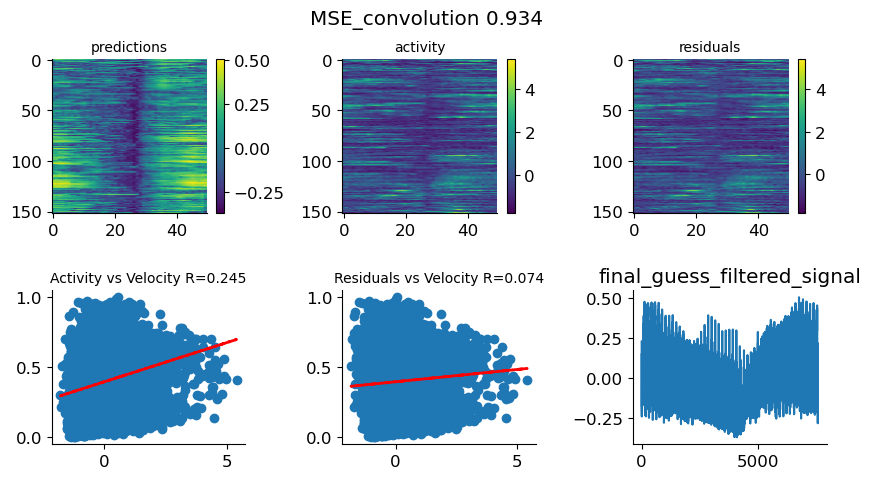

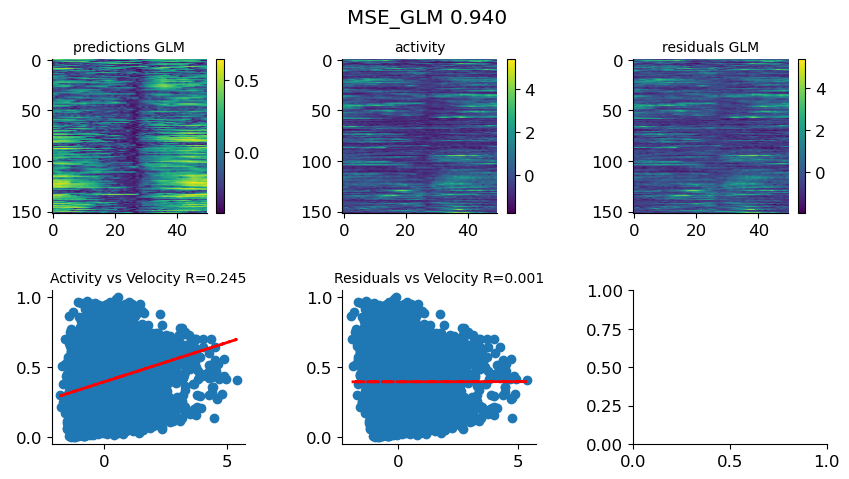

len(optimized_kernel) 51
True Bias: 2.5
Optimized Bias: -0.3961991144256027


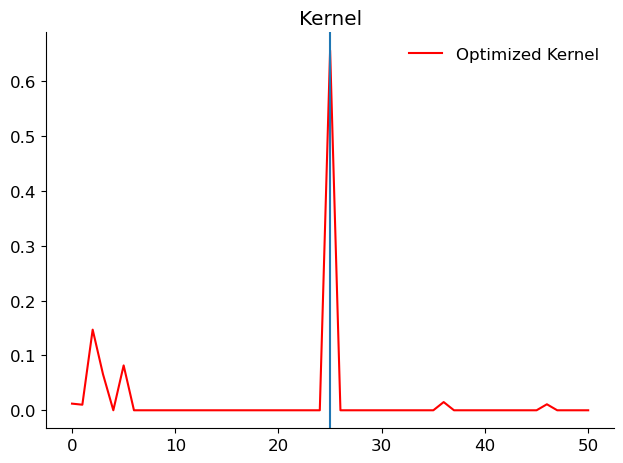

kernel sum 1.0


In [229]:
def get_kernel(kernel_length=50, kernel_tau=0.2, center=0.0):
    kernel_t = np.linspace(-1., 1., kernel_length)
    kernel = np.exp(-((kernel_t - center) / kernel_tau)**2.)
    kernel /= np.sum(kernel)
    return kernel 

cell_number = 12

kernel_length = 51

per_cell_velocity = []
for animal in activity_dict_SST:
    for neuron in activity_dict_SST[animal]:
        per_cell_velocity.append(factors_dict_SST[animal]['Velocity'])

activity_list = []
for animal in activity_dict_SST:
    for neuron in activity_dict_SST[animal]:
        activity_list.append(activity_dict_SST[animal][neuron])
        
example_cell_activity = activity_list[cell_number].flatten()
example_cell_velocity = per_cell_velocity[cell_number].flatten()


def blind_deconvolve_error(params, filtered_signal, orig_signal, return_signal=False):    
    kernel = params[:-1] 
    bias = params[-1]  

    kernel /= np.sum(kernel)

    guess_filtered_signal = np.convolve(orig_signal, kernel, mode='same')[:len(orig_signal)] + bias

    error = np.sum(np.square(filtered_signal - guess_filtered_signal))
    
    if return_signal:
        return error, guess_filtered_signal
    else:
        return error


init_guess_kernel = np.random.uniform(0, 1, kernel_length)
init_guess_bias = [0.0] 
initial_guess = np.concatenate([init_guess_kernel, init_guess_bias])

bounds = [(0, 1)] * kernel_length + [(-5, 5)]

# result = minimize(blind_deconvolve_error, x0=initial_guess, args=(smoothed_ts_with_bias, ts), bounds=bounds)
result = minimize(blind_deconvolve_error, x0=initial_guess, args=(example_cell_activity, example_cell_velocity), bounds=bounds, method="L-BFGS-B", options={"maxiter: 1000})

final_error, final_guess_filtered_signal = blind_deconvolve_error(result.x, example_cell_activity, example_cell_velocity, return_signal=True)


predictions=final_guess_filtered_signal.reshape(activity_list[cell_number].shape)
activity = example_cell_activity.reshape(activity_list[cell_number].shape)
residuals = activity-predictions
MSE_convolution = np.mean(np.square(residuals))




fig, axs = plt.subplots(2, 3, figsize=(10,5))

fig.suptitle(f"MSE_convolution {MSE_convolution:.3f}")
fig.subplots_adjust(wspace=0.5, hspace=0.5)

plt.plot(final_guess_filtered_signal)
plt.title("final_guess_filtered_signal")

axs[0,0].set_title("predictions", fontsize=10)
im1 = axs[0,0].imshow(predictions.T, aspect='auto')
cbar1 = fig.colorbar(im1, ax=axs[0,0])

axs[0,1].set_title("activity", fontsize=10)
im2 = axs[0,1].imshow(activity.T, aspect='auto')
cbar2 = fig.colorbar(im2, ax=axs[0,1])

axs[0,2].set_title("residuals", fontsize=10)
im3 = axs[0,2].imshow(residuals.T, aspect='auto')
cbar3 = fig.colorbar(im3, ax=axs[0,2])


len_activity = len(example_cell_activity)

activity_velocity_correlation, _ = pearsonr(example_cell_activity, example_cell_velocity)
slope, intercept, r_value, p_value, std_err = linregress(example_cell_activity, example_cell_velocity)
trend_line_activity = intercept + slope * example_cell_activity

axs[1,0].set_title(f"Activity vs Velocity R={activity_velocity_correlation:.3f}", fontsize=10)
axs[1,0].scatter(example_cell_activity, example_cell_velocity)
axs[1,0].plot(example_cell_activity, trend_line_activity, color="red", linewidth=2, linestyle="dashed", label=f"Trend (slope={slope:.4f})")

flat_residuals = residuals.flatten()

residuals_velocity_correlation, _ = pearsonr(flat_residuals, example_cell_velocity)
slope, intercept, r_value, p_value, std_err = linregress(flat_residuals, example_cell_velocity)
trend_line_residuals = intercept + slope * flat_residuals

axs[1,1].set_title(f"Residuals vs Velocity R={residuals_velocity_correlation:.3f}", fontsize=10)
axs[1,1].scatter(flat_residuals, example_cell_velocity)
axs[1,1].plot(flat_residuals, trend_line_residuals, color="red", linewidth=2, linestyle="dashed", label=f"Trend (slope={slope:.4f})")




plt.tight_layout
plt.show()


################################# GLM prediction 



alphas=None

model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)

model.fit(example_cell_velocity.reshape(-1, 1), example_cell_activity)

neuron_predicted_activity = model.predict(example_cell_velocity.reshape(-1, 1))

neuron_predicted_activity = neuron_predicted_activity.reshape(predictions.shape)

residuals_GLM = activity - neuron_predicted_activity

MSE_GLM = np.mean(np.square(residuals_GLM))


fig, axs = plt.subplots(2, 3, figsize=(10,5))

fig.suptitle(f"MSE_GLM {MSE_GLM:.3f}")
fig.subplots_adjust(wspace=0.5, hspace=0.5)

axs[0, 0].set_title("predictions GLM", fontsize=10)
im1 = axs[0, 0].imshow(neuron_predicted_activity.T, aspect='auto')
cbar1 = fig.colorbar(im1, ax=axs[0, 0])

axs[0, 1].set_title("activity", fontsize=10)
im2 = axs[0, 1].imshow(activity.T, aspect='auto')
cbar2 = fig.colorbar(im2, ax=axs[0, 1])

axs[0, 2].set_title("residuals GLM", fontsize=10)
im3 = axs[0, 2].imshow(residuals_GLM.T, aspect='auto')
cbar2 = fig.colorbar(im3, ax=axs[0, 2])



len_activity = len(example_cell_activity)

activity_velocity_correlation, _ = pearsonr(example_cell_activity, example_cell_velocity)
slope, intercept, r_value, p_value, std_err = linregress(example_cell_activity, example_cell_velocity)
trend_line_activity = intercept + slope * example_cell_activity

axs[1,0].set_title(f"Activity vs Velocity R={activity_velocity_correlation:.3f}", fontsize=10)
axs[1,0].scatter(example_cell_activity, example_cell_velocity)
axs[1,0].plot(example_cell_activity, trend_line_activity, color="red", linewidth=2, linestyle="dashed", label=f"Trend (slope={slope:.4f})")

flat_residuals = residuals_GLM.flatten()

residuals_velocity_correlation, _ = pearsonr(flat_residuals, example_cell_velocity)
slope, intercept, r_value, p_value, std_err = linregress(flat_residuals, example_cell_velocity)
trend_line_residuals = intercept + slope * flat_residuals

axs[1,1].set_title(f"Residuals vs Velocity R={residuals_velocity_correlation:.3f}", fontsize=10)
axs[1,1].scatter(flat_residuals, example_cell_velocity)
axs[1,1].plot(flat_residuals, trend_line_residuals, color="red", linewidth=2, linestyle="dashed", label=f"Trend (slope={slope:.4f})")



plt.tight_layout
plt.show()





##################################33





optimized_kernel = result.x[:-1]
optimized_bias = result.x[-1]

optimized_kernel /= np.sum(optimized_kernel)

print(f"len(optimized_kernel) {len(optimized_kernel)}")

print(f"True Bias: {true_bias}")
print(f"Optimized Bias: {optimized_bias}")

plt.figure()
plt.plot(optimized_kernel, color='r', label="Optimized Kernel")
plt.axvline(x=25)
# plt.plot(kernel_ground_truth, color='b', label="Kernel Ground Truth")
plt.title("Kernel")
plt.legend()

plt.tight_layout()
plt.show()

print(f"kernel sum {np.sum(optimized_kernel)}")



### def fit_GLM_population(factors_dict, activity_dict, quintile=None, regression='ridge', renormalize=True, alphas=None):
    GLM_params = {}
    predicted_activity_dict = {}

    for animal in factors_dict:
        GLM_params[animal] = {}
        predicted_activity_dict[animal] = {}
        _factors_dict = factors_dict[animal].copy()

        if quintile is not None:
            num_trials = _factors_dict['Activity'].shape[1]
            start_idx, end_idx = get_quintile_indices(num_trials, quintile)
            for var in _factors_dict:
                _factors_dict[var] = _factors_dict[var][:, start_idx:end_idx]

        if renormalize:
            normalize_data(_factors_dict)

        for neuron_idx in activity_dict[animal]:
            neuron_activity = activity_dict[animal][neuron_idx]

            neuron_GLM_params, neuron_predicted_activity = fit_GLM(_factors_dict, neuron_activity, regression, alphas)

            GLM_params[animal][neuron_idx] = neuron_GLM_params
            predicted_activity_dict[animal][neuron_idx] = neuron_predicted_activity.reshape(
                activity_dict[animal][neuron_idx].shape)

    return GLM_params, predicted_activity_dict


def fit_GLM(factors_dict, neuron_activity, regression='ridge', alphas=None):
    neuron_activity_flat = neuron_activity.flatten()
    flattened_data = flatten_data(factors_dict)

    variable_names = [var for var in flattened_data]
    design_matrix_X = np.stack([flattened_data[var] for var in variable_names], axis=1)

    if regression == 'lasso':
        model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
    elif regression == 'ridge':
        model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
    elif regression == 'elastic':
        l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
        model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000],
                             l1_ratio=l1_ratio, cv=None)
    else:
        raise ValueError("Regression type must be 'lasso' or 'ridge'")

    model.fit(design_matrix_X, neuron_activity_flat)

    neuron_predicted_activity = model.predict(design_matrix_X)

    trialavg_neuron_activity = np.mean(neuron_activity, axis=1)
    trialavg_predicted_activity = np.mean(neuron_predicted_activity.reshape(neuron_activity.shape), axis=1)
    pearson_R = np.corrcoef(trialavg_predicted_activity, trialavg_neuron_activity)[0, 1]

    neuron_GLM_params = {}
    neuron_GLM_params['weights'] = {var: model.coef_[idx] for idx, var in enumerate(variable_names)}
    neuron_GLM_params['intercept'] = model.intercept_
    neuron_GLM_params['alpha'] = model.alpha_ if regression == 'ridge' else model.alpha_
    neuron_GLM_params['l1_ratio'] = model.l1_ratio_ if regression == 'elastic' else None
    neuron_GLM_params['R2'] = model.score(design_matrix_X, neuron_activity_flat)
    neuron_GLM_params['pearson_R'] = pearson_R
    neuron_GLM_params['model'] = model

    return neuron_GLM_params, neuron_predicted_activity
